# Callable Bond Pricing

A callable bond gives the **issuer** the right -- but not the obligation -- to redeem
the bond before maturity at a pre-specified call price (usually par). The issuer
will exercise this right when interest rates fall below the bond's coupon rate,
allowing them to refinance at a lower cost.

From the investor's perspective, a callable bond is a:

$$\text{Callable Bond} = \text{Straight Bond} - \text{Call Option (owned by issuer)}$$

The investor receives a higher coupon to compensate for selling the call option
to the issuer. This extra yield is the **option-adjusted spread (OAS)**.

**Why callable bonds are hard to price:**
The call option is path-dependent -- whether it is exercised depends on the
entire path of interest rates, not just the rate at one point. This rules out
simple discounted cash flow. We need models that capture the full distribution
of future rate paths.

**Three pricing approaches covered:**
1. **Binomial tree** -- discrete lattice of rate scenarios, backward induction
2. **OAS** -- option-adjusted spread, the yield spread after removing the option value
3. **Monte Carlo** -- simulate thousands of rate paths, price on each, average

**Regulatory context:**
- IFRS 13 -- Level 2 fair value (observable inputs), Level 3 if model-dependent
- FRTB SA -- OAS feeds into CSR-NS delta sensitivity
- IRRBB -- callable bonds complicate EVE calculation (uncertain cash flow timing)

---
*Notebook QRE-73 | Module 1 -- Yield Curves and Asset Pricing*


**Call schedule:**
The issuer can call the bond on specific dates (European call) or any coupon
date after a lockout period (American/Bermuda call). The call price is usually
par (100) but may step down over time (declining call price schedule).

**Issuer's rational call decision:**
The issuer calls when the bond's fair value (if straight) exceeds the call price.
Equivalently: when the market yield drops below the coupon rate, the issuer can
refinance more cheaply. The call option is in-the-money when:

$$V_{straight}(r_t) > \text{Call Price}$$

**Investor's yield measures:**

| Measure | Definition | When to use |
|---------|-----------|-------------|
| YTM | Yield assuming held to maturity | Never called |
| YTC | Yield assuming called at first call date | Always called |
| YTW | Min(YTM, YTC) -- yield to worst | Conservative measure |
| OAS | Spread over risk-free after removing option value | True credit spread |

**The option cost:**
$$\text{Call option value} = V_{straight} - V_{callable}$$

The callable bond always trades below the straight bond (the option has positive
value for the issuer). As rates fall, the straight bond price rises but the
callable bond price is capped near the call price -- **price compression**.

In [1]:
from datetime import datetime

from quant_risk.setup import base, macro, asset_pricing
np, pd, plt = base()
ois_curve, nss_curve, valuation_date, calendar, ql = asset_pricing()
fed_client, store, external_store = macro()

from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

C1, C2, C3, C4 = '#2E75B6', '#ED7D31', '#A9D18E', '#C00000'
day_count = ql.Actual365Fixed()

base loaded
OISCurve | currency=EUR | valuation_date=2026-03-24
NSSCurve | currency=EUR | valuation_date=2026-05-05
Valuation date : March 24th, 2026
Calendar       : TARGET
asset pricing loaded
macro loaded


In [2]:
# straight bond object 

# ── dates and calendar ────────────────────────────────────────────────────────
val_date = datetime.strptime(ois_curve.valuation_date, "%Y-%m-%d")
today    = ql.Date(val_date.day, val_date.month, val_date.year)
ql.Settings.instance().evaluationDate = today

calendar   = ql.TARGET()
day_count  = ql.Actual365Fixed()
convention = ql.ModifiedFollowing

# ── bond parameters ───────────────────────────────────────────────────────────
face          = 100.0
coupon_rate   = 0.04
maturity      = calendar.advance(today, 5, ql.Years)
credit_spread = 0.0120

# ── curves ────────────────────────────────────────────────────────────────────
ois_handle    = ql.YieldTermStructureHandle(ois_curve._ql_curve)
spread_handle = ql.QuoteHandle(ql.SimpleQuote(credit_spread))
credit_handle = ql.YieldTermStructureHandle(
    ql.ZeroSpreadedTermStructure(ois_handle, spread_handle)
)

# ── schedule ──────────────────────────────────────────────────────────────────
schedule = ql.Schedule(
    today, maturity,
    ql.Period(ql.Annual),
    calendar,
    convention, convention,
    ql.DateGeneration.Backward, False
)

In [3]:
# pricing engine for straight bond: discounting with credit-adjusted curve

# ── straight bond ─────────────────────────────────────────────────────────────
straight_bond = ql.FixedRateBond(
    0, face, schedule,
    [coupon_rate], day_count
)
straight_bond.setPricingEngine(ql.DiscountingBondEngine(credit_handle))
price_straight = straight_bond.cleanPrice()

In [4]:
# callable bond object - use the same coupon schedule AND add call schedule

call_price= 100.0

# ── call schedule ─────────────────────────────────────────────────────────────
call_schedule = ql.CallabilitySchedule()
for y in range(2, 5):
    call_date = calendar.advance(today, y, ql.Years)
    call_schedule.append(
        ql.Callability(
            ql.BondPrice(face, ql.BondPrice.Clean),
            ql.Callability.Call,
            call_date
        )
    )

# ── callable bond ─────────────────────────────────────────────────────────────
callable_bond = ql.CallableFixedRateBond(
    0, face, schedule,
    [coupon_rate], day_count,
    convention, face,
    today, call_schedule
)

In [5]:
# pricing engine for THE CALLABLE bond: Hull-White short rate model

# ── Hull-White trinomial tree ────────────────────────────────────────────────
sigma_hw = 0.010
mean_rev = 0.030
hw_model = ql.HullWhite(credit_handle, mean_rev, sigma_hw)
engine   = ql.TreeCallableFixedRateBondEngine(hw_model, 100)
callable_bond.setPricingEngine(engine)

In [6]:
price_callable = callable_bond.cleanPrice()
option_value   = price_straight - price_callable

print(f"Valuation date:       {ois_curve.valuation_date}")
print(f"Straight bond price:  {price_straight:.4f}")
print(f"Callable bond price:  {price_callable:.4f}")
print(f"Call option value:    {option_value:.4f}")
print(f"Credit spread:        {credit_spread*10000:.0f}bps")

print("\nHW - Hull-White model parameters used for tree:")
print(f"HW sigma:             {sigma_hw*100:.1f}%")
print(f"HW mean reversion:    {mean_rev*100:.1f}%")

Valuation date:       2026-03-24
Straight bond price:  101.7468
Callable bond price:  99.7770
Call option value:    1.9698
Credit spread:        120bps

HW - Hull-White model parameters used for tree:
HW sigma:             1.0%
HW mean reversion:    3.0%


## 2. Binomial/trinomial Tree Pricing

The tree models the evolution of the short rate over discrete time
steps. At each node the rate moves up or down with equal probability under
the risk-neutral measure. The callable bond is priced by backward induction:
starting at maturity with known values (face + coupon) and working backwards,
applying the call decision at each node.

**Rate evolution models**

Two common choices for the short rate process:
**Short rate models for tree pricing**

| | Ho-Lee | Hull-White |
|---|---|---|
| Tree type | Binomial | Trinomial |
| Parameters | $\sigma$ only | $\sigma$ and $a$ (mean reversion) |
| Mean reversion | No | Yes |
| Calibration | Drift $\theta_t$ fitted to yield curve | $\theta_t$ fitted to yield curve, $\sigma$ and $a$ to swaptions |
| Rate fan | Grows unboundedly | Stabilises over time |
| Nodes at step $i$ | $i+1$ | $2i+1$ |
| Typical use | Pedagogy, simple models | Industry standard for IR derivatives |
| Model |$r_{t+\Delta t} = r_t + \theta_t \,\Delta t + \sigma \sqrt{\Delta t} \cdot \epsilon$ | $dr_t = (\theta_t - a \, r_t)\,dt + \sigma \, dW_t$|


**Backward induction and call decision**

At maturity: $V = \text{face} + \text{coupon}$

At each earlier node, the hold value is:

$$V_{hold} = 0.5\,(V_{up} + V_{down})\,e^{-r\,\Delta t} + \text{coupon}$$

In the call period, the issuer calls whenever $V_{hold} > V_{call}$, so:

$$V_{node} = \min(V_{hold},\, V_{call})$$

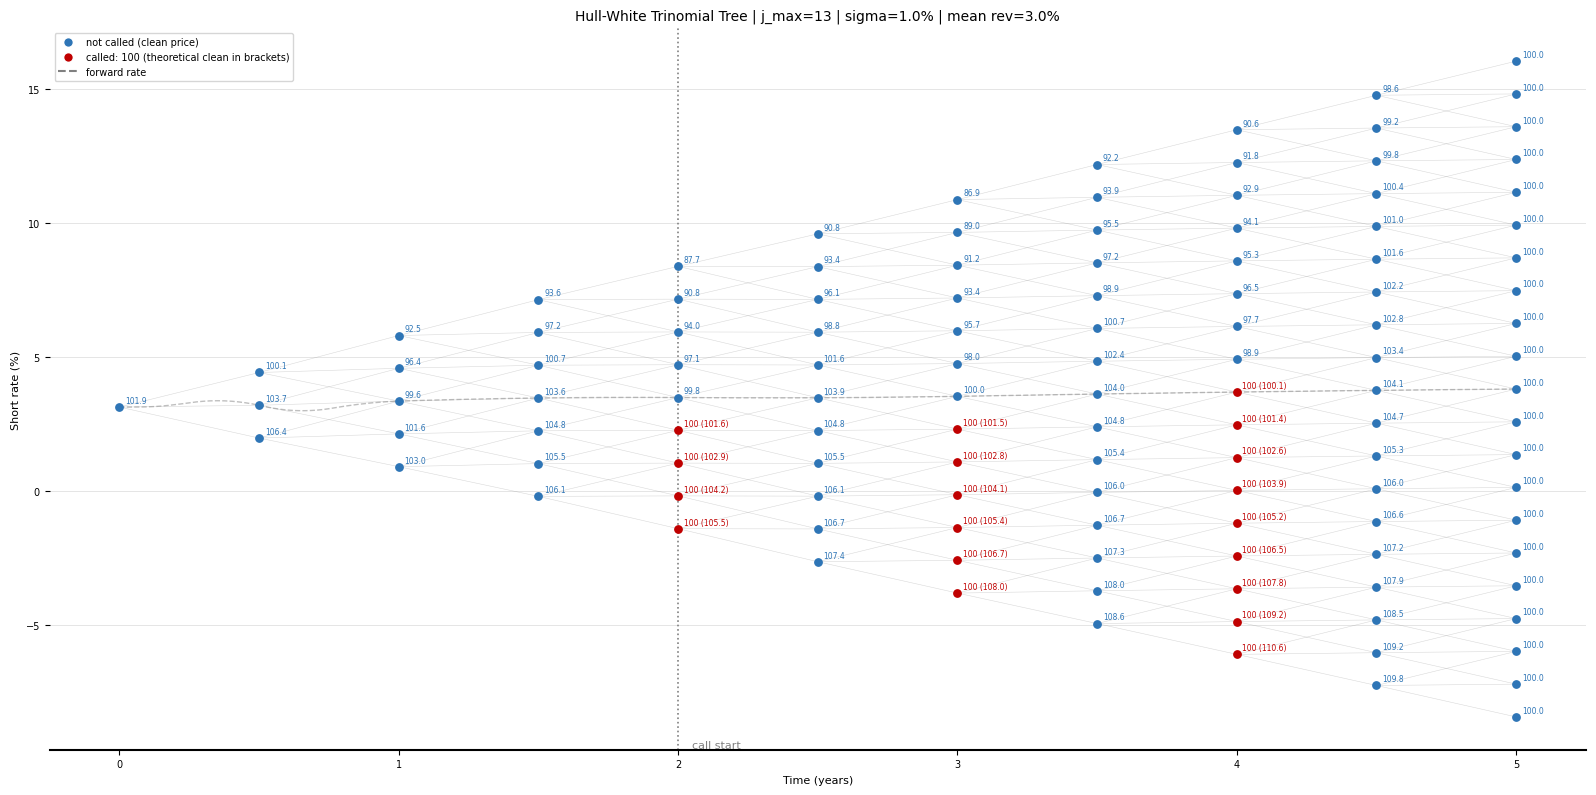

Tree root price (dirty): 103.9300
Tree root price (clean): 101.9300
QuantLib tree price:     99.7770


In [9]:
# ── Hull-White trinomial tree (proper implementation) ─────────────────────────
# Following Hull & White (1994) trinomial tree construction
# dx = sigma * sqrt(3*dt), mean reversion handled via branching probabilities

n_steps    = 10
dt         = 0.5
sigma      = sigma_hw
a          = mean_rev
dx         = sigma * np.sqrt(3 * dt)
call_price = 100.0

coupon_steps  = {2, 4, 6, 8, 10}
call_steps    = {4, 6, 8}
coupon_annual = coupon_rate * face

# ── step 1: build node indices and rates ──────────────────────────────────────
# at step i, nodes are indexed by j where r(i,j) = alpha(i) + j*dx
# j ranges from -j_max to +j_max where j_max = min(i, ceil(0.184/(a*dt)))
# this is the Hull-White branching constraint

j_max = int(np.ceil(0.184 / (a * dt)))

def get_alpha(i):
    t = i * dt
    if t < 0.001:
        return credit_handle.forwardRate(0.001, 0.002, ql.Continuous, ql.Annual).rate()
    return credit_handle.forwardRate(t, t + 0.001, ql.Continuous, ql.Annual).rate()

# branching probabilities at node j (Hull & White 1994)
def branch_probs(j):
    eta = j * a * dt   # mean reversion pull
    if j >= j_max:
        # top node: branches go (0, -1, -2) -- all downward
        pu = 1/6 + (eta**2 + eta) / 2
        pm = -1/3 - eta**2
        pd = 7/6 + (eta**2 - eta) / 2
        dj = (0, -1, -2)
    elif j <= -j_max:
        # bottom node: branches go (2, 1, 0) -- all upward
        pu = 7/6 + (eta**2 + eta) / 2
        pm = -1/3 - eta**2
        pd = 1/6 + (eta**2 - eta) / 2
        dj = (2, 1, 0)
    else:
        # normal branching: (1, 0, -1)
        pu = 1/6 + (eta**2 - eta) / 2
        pm = 2/3 - eta**2
        pd = 1/6 + (eta**2 + eta) / 2
        dj = (1, 0, -1)
    return pu, pm, pd, dj

# ── step 2: backward induction ────────────────────────────────────────────────
node_values = {}
node_hold   = {}
node_called = {}
node_rates  = {}

# build rates at all nodes
for i in range(n_steps + 1):
    alpha = get_alpha(i)
    j_lim = min(i, j_max)
    for j in range(-j_lim, j_lim + 1):
        node_rates[(i, j)] = alpha + j * dx

# terminal nodes
j_lim = min(n_steps, j_max)
for j in range(-j_lim, j_lim + 1):
    node_values[(n_steps, j)] = face + coupon_annual
    node_hold[(n_steps, j)]   = face + coupon_annual
    node_called[(n_steps, j)] = False

# backward induction
for i in range(n_steps - 1, -1, -1):
    j_lim = min(i, j_max)
    for j in range(-j_lim, j_lim + 1):
        r             = node_rates[(i, j)]
        pu, pm, pd, dj = branch_probs(j)

        v_u = node_values.get((i + 1, j + dj[0]), face)
        v_m = node_values.get((i + 1, j + dj[1]), face)
        v_d = node_values.get((i + 1, j + dj[2]), face)

        v_hold = (pu * v_u + pm * v_m + pd * v_d) * np.exp(-r * dt)
        if (i + 1) in coupon_steps:
            v_hold += coupon_annual
        node_hold[(i, j)] = v_hold

        if i in call_steps:
            called = v_hold > (call_price + coupon_annual)
            v_node = (call_price + coupon_annual) if called else v_hold
        else:
            called = False
            v_node = v_hold

        node_values[(i, j)] = v_node
        node_called[(i, j)] = called

# ── step 3: plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))

# forward rate reference
times_cont = np.linspace(0, n_steps * dt, 200)
fwd_cont   = np.array([
    credit_handle.forwardRate(t, t + 0.001, ql.Continuous, ql.Annual).rate()
    for t in times_cont
])
ax.plot(times_cont, fwd_cont * 100, color='grey', linewidth=1,
        linestyle='--', alpha=0.5, label='forward rate', zorder=1)

for i in range(n_steps + 1):
    j_lim = min(i, j_max)
    for j in range(-j_lim, j_lim + 1):
        r_node = node_rates[(i, j)]
        called = node_called.get((i, j), False)
        color  = C4 if called else C1

        ax.scatter(i * dt, r_node * 100, color=color, s=28, zorder=5)

        if i in coupon_steps:
            accrued = coupon_annual
        else:
            accrued = coupon_annual * dt

        v_clean      = node_values[(i, j)] - accrued
        v_hold_clean = node_hold[(i, j)] - accrued

        label = f"100 ({v_hold_clean:.1f})" if called else f"{v_clean:.1f}"
        ax.annotate(label, (i * dt, r_node * 100),
                    textcoords='offset points', xytext=(4, 3),
                    fontsize=5.5, color=color)

        # branches
        if i < n_steps:
            _, _, _, dj = branch_probs(j)
            alpha_next  = get_alpha(i + 1)
            for d in dj:
                j_next = j + d
                if abs(j_next) <= min(i + 1, j_max):
                    r_next = alpha_next + j_next * dx
                    ax.plot([i * dt, (i + 1) * dt],
                            [r_node * 100, r_next * 100],
                            color='grey', linewidth=0.4, alpha=0.3)

ax.axvline(x=2, color='grey', linestyle=':', linewidth=1.2)
ax.text(2.05, ax.get_ylim()[0] + 0.05, 'call start', fontsize=8, color='grey')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C1, markersize=7, label='not called (clean price)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C4, markersize=7, label='called: 100 (theoretical clean in brackets)'),
    Line2D([0], [0], color='grey', linestyle='--', label='forward rate'),
]
ax.legend(handles=legend_elements)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Short rate (%)')
ax.set_title(f'Hull-White Trinomial Tree | j_max={j_max} | sigma={sigma*100:.1f}% | mean rev={a*100:.1f}%')
plt.tight_layout()
plt.show()

print(f"Tree root price (dirty): {node_values[(0,0)]:.4f}")
print(f"Tree root price (clean): {node_values[(0,0)] - coupon_annual * dt:.4f}")
print(f"QuantLib tree price:     {price_callable:.4f}")

## 3. Option-Adjusted Spread (OAS)

The z-spread of a callable bond is misleading -- it includes compensation
for both credit risk AND the call option sold to the issuer. The OAS
removes the option component and gives the pure credit spread.

**Definition:**
The OAS is the constant spread added to every node of the rate tree such
that the model price equals the market price:

$$P_{market} = f(\text{rate tree} + OAS)$$

Where $f$ is the callable bond pricing function (backward induction).

**OAS vs Z-spread:**

| Measure | What it captures | Model needed |
|---------|-----------------|-------------|
| Z-spread | Credit risk + option cost | No -- just DCF |
| OAS | Credit risk only | Yes -- rate model |

OAS < Z-spread: the difference is the option cost embedded in the z-spread.

**Practical use:**
- Compare callable bonds across different call structures on a fair basis
- A callable bond with OAS > non-callable bond with same credit = callable is cheap
- FRTB: OAS is the sensitivity input for CSR-NS delta on callable bonds

In [11]:
# ── OAS computation ───────────────────────────────────────────────────────────
# OAS: constant spread added to every node of the HW tree such that
# model price = market price

market_price = price_callable - 0.50   # assume market trades 50c below model

# OAS via QuantLib: shift the credit curve by OAS and reprice
oas_bps = callable_bond.OAS(
    market_price,
    credit_handle,
    day_count,
    ql.Continuous,
    ql.Annual
)
oas = oas_bps   # QuantLib returns OAS in decimal

# z-spread of the callable bond via QuantLib
z_spread = ql.BondFunctions.zSpread(
    callable_bond,
    ql.BondPrice(market_price, ql.BondPrice.Clean),
    credit_handle.currentLink(),
    day_count,
    ql.Continuous,
    ql.Annual,
    today
)


print(f"OAS Analysis -- Callable Bond")
print(f"  Market price:          {market_price:.4f}")
print(f"  Model price (tree):    {price_callable:.4f}")
print(f"\n  Z-spread:              {z_spread*10000:.2f}bps")
print(f"  OAS:                   {oas*10000:.2f}bps")
print(f"  Option cost (Z - OAS): {(z_spread - oas)*10000:.2f}bps")
print(f"\n  Interpretation:")
print(f"  The bond offers {z_spread*10000:.0f}bps total spread over OIS.")
print(f"  Of this, {(z_spread-oas)*10000:.0f}bps compensates for the call option.")
print(f"  The pure credit spread (OAS) is {oas*10000:.0f}bps.")

OAS Analysis -- Callable Bond
  Market price:          99.2770
  Model price (tree):    99.7770

  Z-spread:              52.32bps
  OAS:                   15.62bps
  Option cost (Z - OAS): 36.70bps

  Interpretation:
  The bond offers 52bps total spread over OIS.
  Of this, 37bps compensates for the call option.
  The pure credit spread (OAS) is 16bps.


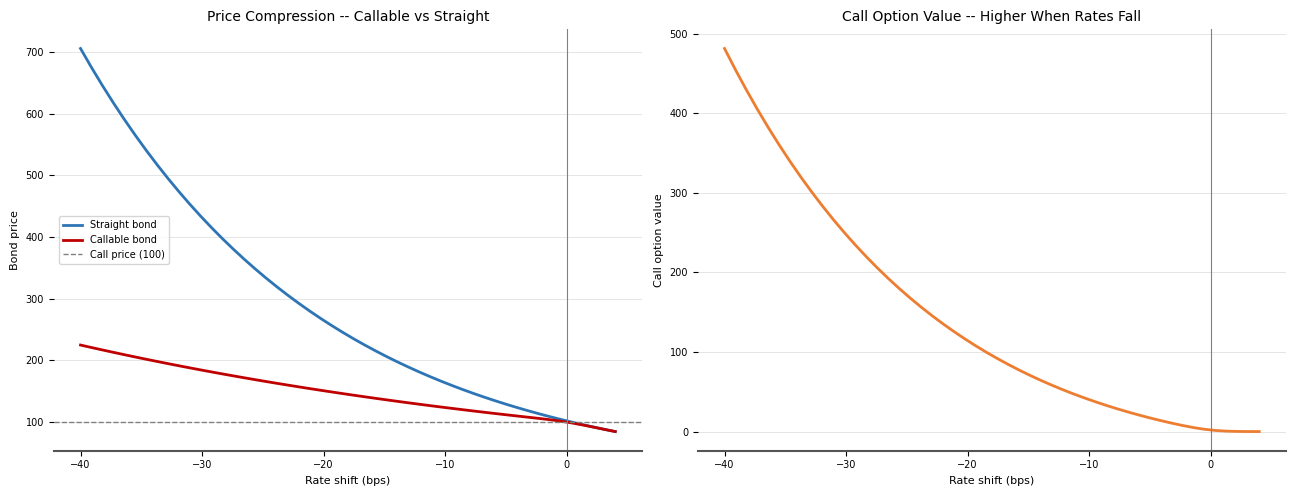

In [ ]:
# ── price compression -- callable vs straight ─────────────────────────────────
rate_shifts = np.linspace(-0.4, 0.04, 50)
prices_straight_shifted = []
prices_callable_shifted = []

for shift in rate_shifts:
    shifted_spread = ql.QuoteHandle(ql.SimpleQuote(shift))
    shifted_ois    = ql.YieldTermStructureHandle(
        ql.ZeroSpreadedTermStructure(ois_handle, shifted_spread)
    )
    shifted_credit = ql.YieldTermStructureHandle(
        ql.ZeroSpreadedTermStructure(shifted_ois,
            ql.QuoteHandle(ql.SimpleQuote(credit_spread)))
    )

    straight_bond.setPricingEngine(ql.DiscountingBondEngine(shifted_credit))
    prices_straight_shifted.append(straight_bond.cleanPrice())

    hw_shifted = ql.HullWhite(shifted_credit, mean_rev, sigma_hw)
    callable_bond.setPricingEngine(
        ql.TreeCallableFixedRateBondEngine(hw_shifted, 100)
    )
    prices_callable_shifted.append(callable_bond.cleanPrice())

# reset engines to original credit curve
straight_bond.setPricingEngine(ql.DiscountingBondEngine(credit_handle))
hw_model = ql.HullWhite(credit_handle, mean_rev, sigma_hw)
callable_bond.setPricingEngine(ql.TreeCallableFixedRateBondEngine(hw_model, 100))

option_values = np.array(prices_straight_shifted) - np.array(prices_callable_shifted)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5))

ax0.plot(rate_shifts * 100, prices_straight_shifted, color=C1, linewidth=2,
             label='Straight bond')
ax0.plot(rate_shifts * 100, prices_callable_shifted, color=C4, linewidth=2,
             label='Callable bond')
ax0.axhline(call_price, color='grey', linestyle='--', linewidth=1,
                label=f'Call price ({call_price:.0f})')
ax0.axvline(0, color='grey', linewidth=0.8)
ax0.set_xlabel('Rate shift (bps)')
ax0.set_ylabel('Bond price')
ax0.set_title('Price Compression -- Callable vs Straight')
ax0.legend()
ax0.spines['bottom'].set_color('#555555')

ax1.plot(rate_shifts * 100, option_values, color=C2, linewidth=2)
ax1.axvline(0, color='grey', linewidth=0.8)
ax1.set_xlabel('Rate shift (bps)')
ax1.set_ylabel('Call option value')
ax1.set_title('Call Option Value -- Higher When Rates Fall')
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

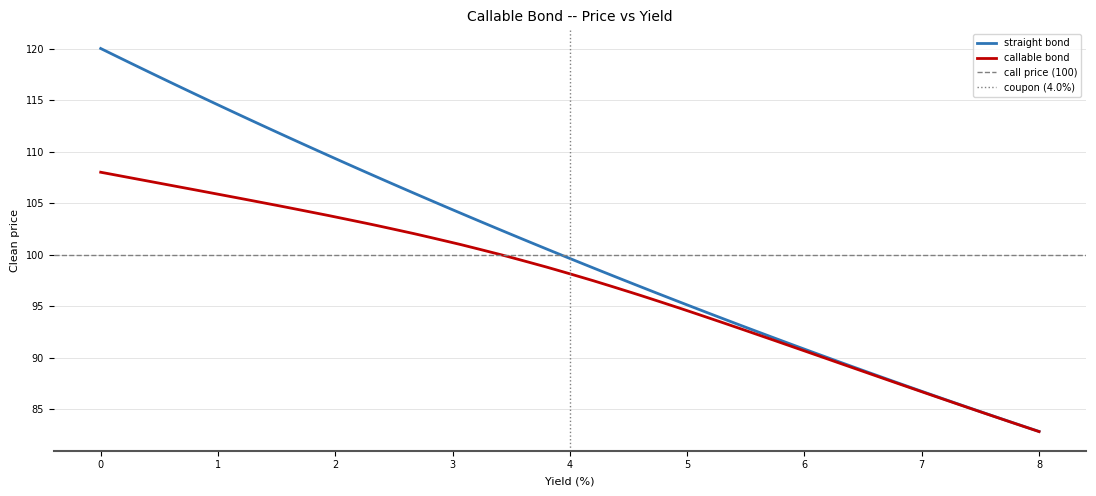

In [25]:
# ── callable bond price vs yield ──────────────────────────────────────────────
yields = np.linspace(.0, 0.08, 100)   # 1% to 8%
prices_straight = []
prices_callable = []

for y in yields:
    # flat yield curve at y
    flat_handle = ql.YieldTermStructureHandle(
        ql.FlatForward(today, y, day_count)
    )

    # straight bond
    straight_bond.setPricingEngine(ql.DiscountingBondEngine(flat_handle))
    prices_straight.append(straight_bond.cleanPrice())

    # callable bond
    hw_y = ql.HullWhite(flat_handle, mean_rev, sigma_hw)
    callable_bond.setPricingEngine(
        ql.TreeCallableFixedRateBondEngine(hw_y, 100)
    )
    prices_callable.append(callable_bond.cleanPrice())

# reset engines
straight_bond.setPricingEngine(ql.DiscountingBondEngine(credit_handle))
hw_model = ql.HullWhite(credit_handle, mean_rev, sigma_hw)
callable_bond.setPricingEngine(ql.TreeCallableFixedRateBondEngine(hw_model, 100))

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(yields * 100, prices_straight, color=C1, linewidth=2, label='straight bond')
ax.plot(yields * 100, prices_callable, color=C4, linewidth=2, label='callable bond')
ax.axhline(call_price, color='grey', linestyle='--', linewidth=1, label=f'call price ({call_price:.0f})')
ax.axvline(coupon_rate * 100, color='grey', linestyle=':', linewidth=1, label=f'coupon ({coupon_rate*100:.1f}%)')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Clean price')
ax.set_title('Callable Bond -- Price vs Yield')
ax.legend()
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

## 4. Monte Carlo Pricing

Monte Carlo prices the callable bond by simulating many short rate paths,
applying the call decision on each path, discounting cash flows, and averaging.

**Short rate simulation -- Hull-White:**

Under Hull-White, the short rate follows:

$$dr_t = (\theta_t - a \, r_t)\,dt + \sigma \, dW_t$$

which has an exact discretisation:

$$r_{t+\Delta t} = r_t \, e^{-a\Delta t} + \alpha(t+\Delta t) - \alpha(t)e^{-a\Delta t} + \sigma\sqrt{\frac{1-e^{-2a\Delta t}}{2a}} \, \epsilon$$

where $\alpha(t)$ is the deterministic shift fitted to the OIS curve and
$\epsilon \sim N(0,1)$.

**The call decision problem:**

In a trinomial tree, the call decision is straightforward: backward induction
gives the exact hold value at every node. In Monte Carlo we simulate forward,
so at any call date we do not know future values without simulating further.

**Longstaff-Schwartz:**

The standard solution regresses future discounted cash flows on current state
variables to estimate the continuation value at each call date. The issuer
calls if the call price exceeds the estimated continuation value. This is the
same algorithm used for American option pricing.

**Convergence:**

Monte Carlo converges at rate $1/\sqrt{N}$. For callable bonds, Longstaff-Schwartz
adds regression noise on top, so in practice 50,000-100,000 paths are needed
for stable prices. The trinomial tree is faster and more accurate for simple
Bermuda structures like this one — Monte Carlo becomes valuable for
path-dependent payoffs or high-dimensional problems.

In [26]:
# ── Monte Carlo rate path simulation -- Hull-White ────────────────────────────
np.random.seed(42)
n_paths    = 10000
n_steps_mc = 20       # monthly steps over 5Y (dt=0.25Y)
dt_mc      = 0.25
sigma_mc   = sigma_hw
a_mc       = mean_rev

def simulate_hw_paths(credit_handle, a, sigma, n_steps, dt, n_paths):
    """
    Simulate Hull-White short rate paths using exact discretisation.

    r_{t+dt} = r_t * exp(-a*dt) + alpha(t+dt) - alpha(t)*exp(-a*dt)
               + sigma * sqrt((1-exp(-2a*dt))/(2a)) * epsilon

    Parameters
    ----------
    credit_handle : QuantLib yield term structure handle (OIS + spread)
    a             : mean reversion speed
    sigma         : short rate volatility
    n_steps       : number of time steps
    dt            : time step size in years
    n_paths       : number of paths
    """
    def alpha(t):
        if t < 1e-6:
            return credit_handle.forwardRate(
                1e-6, 1e-5, ql.Continuous, ql.Annual
            ).rate()
        return credit_handle.forwardRate(
            t, t + 1e-4, ql.Continuous, ql.Annual
        ).rate()

    std_dev = sigma * np.sqrt((1 - np.exp(-2 * a * dt)) / (2 * a))

    paths      = np.zeros((n_paths, n_steps + 1))
    paths[:,0] = alpha(0)

    for i in range(n_steps):
        t      = i * dt
        t_next = (i + 1) * dt
        mean_reversion_factor = np.exp(-a * dt)
        drift  = alpha(t_next) - alpha(t) * mean_reversion_factor
        eps    = np.random.standard_normal(n_paths)
        paths[:, i+1] = paths[:, i] * mean_reversion_factor + drift + std_dev * eps

    return paths


rate_paths_mc = simulate_hw_paths(
    credit_handle, a_mc, sigma_mc, n_steps_mc, dt_mc, n_paths
)

print(f"Hull-White Monte Carlo -- {n_paths:,} paths, {n_steps_mc} steps, dt={dt_mc}Y")
print(f"\nRate statistics at each step:")
print(f"{'Step':<6} {'Time':>6} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 56)
for i in range(0, n_steps_mc + 1, 4):
    t = i * dt_mc
    print(f"{i:<6} {t:>6.2f} "
          f"{rate_paths_mc[:,i].mean()*100:>9.3f}% "
          f"{rate_paths_mc[:,i].std()*100:>9.3f}% "
          f"{rate_paths_mc[:,i].min()*100:>9.3f}% "
          f"{rate_paths_mc[:,i].max()*100:>9.3f}%")

Hull-White Monte Carlo -- 10,000 paths, 20 steps, dt=0.25Y

Rate statistics at each step:
Step     Time       Mean        Std        Min        Max
--------------------------------------------------------
0        0.00     3.135%     0.000%     3.135%     3.135%
4        1.00     3.354%     0.998%    -0.411%     7.239%
8        2.00     3.497%     1.377%    -1.628%     8.813%
12       3.00     3.548%     1.659%    -2.630%    10.270%
16       4.00     3.709%     1.881%    -2.830%    11.563%
20       5.00     3.818%     2.085%    -4.160%    12.055%


In [27]:
# ── Monte Carlo callable bond pricing -- Longstaff-Schwartz ──────────────────
# Call dates: years 2, 3, 4 (steps 8, 12, 16 with dt=0.25)
call_steps_mc = [8, 12, 16]

def price_callable_mc_ls(rate_paths, dt, coupon_rate, face, call_price,
                          coupon_steps_mc, call_steps_mc):
    """
    Price callable bond via Longstaff-Schwartz regression.

    At each call date, regress discounted future cash flows on current
    short rate to estimate continuation value. Issuer calls if
    call price > continuation value.

    Parameters
    ----------
    coupon_steps_mc : steps where annual coupon is paid
    call_steps_mc   : steps where issuer can call
    """
    n_paths, n_steps_plus1 = rate_paths.shape
    n_steps    = n_steps_plus1 - 1
    coupon     = coupon_rate * face

    # ── step 1: simulate cash flows forward ──────────────────────────────────
    # store cash flows at each step for each path
    cf = np.zeros((n_paths, n_steps + 1))

    # terminal cash flow: face + coupon at maturity
    cf[:, n_steps] = face + coupon

    # coupon cash flows at each coupon date
    for s in coupon_steps_mc:
        if s < n_steps:
            cf[:, s] += coupon

    # ── step 2: backward induction with LS regression ────────────────────────
    # running present value from each step to maturity
    pv = cf[:, n_steps].copy()

    for i in range(n_steps - 1, -1, -1):
        # discount pv back one step
        pv = pv * np.exp(-rate_paths[:, i] * dt)

        # add cash flow at this step
        pv += cf[:, i]

        # call decision at call dates
        if i in call_steps_mc:
            # regress pv on short rate to estimate continuation value
            r      = rate_paths[:, i]
            X      = np.column_stack([np.ones(n_paths), r, r**2, r**3])
            coeffs = np.linalg.lstsq(X, pv, rcond=None)[0]
            cont_value = X @ coeffs

            # issuer calls where continuation value > call price + coupon
            called     = cont_value > (call_price + coupon)
            pv[called] = call_price + coupon

    mc_price = np.mean(pv)
    mc_std   = np.std(pv) / np.sqrt(n_paths)

    return mc_price, mc_std, pv


# coupon paid annually: steps 4, 8, 12, 16, 20 (every 4 steps with dt=0.25)
coupon_steps_mc = [4, 8, 12, 16, 20]

mc_price, mc_std, pv_paths = price_callable_mc_ls(
    rate_paths_mc, dt_mc, coupon_rate, face,
    call_price, coupon_steps_mc, call_steps_mc
)

print(f"Monte Carlo Results -- {n_paths:,} paths (Longstaff-Schwartz)")
print(f"  MC callable bond price:  {mc_price:.4f}")
print(f"  MC standard error:       ±{mc_std:.4f}")
print(f"  95% CI:                  [{mc_price - 1.96*mc_std:.4f}, {mc_price + 1.96*mc_std:.4f}]")
print(f"\nComparison:")
print(f"  QuantLib tree:           {price_callable:.4f}")
print(f"  Monte Carlo (LS):        {mc_price:.4f}")
print(f"  Difference:              {abs(mc_price - price_callable):.4f}")

Monte Carlo Results -- 10,000 paths (Longstaff-Schwartz)
  MC callable bond price:  100.0703
  MC standard error:       ±0.0319
  95% CI:                  [100.0077, 100.1329]

Comparison:
  QuantLib tree:           99.7770
  Monte Carlo (LS):        100.0703
  Difference:              0.2933


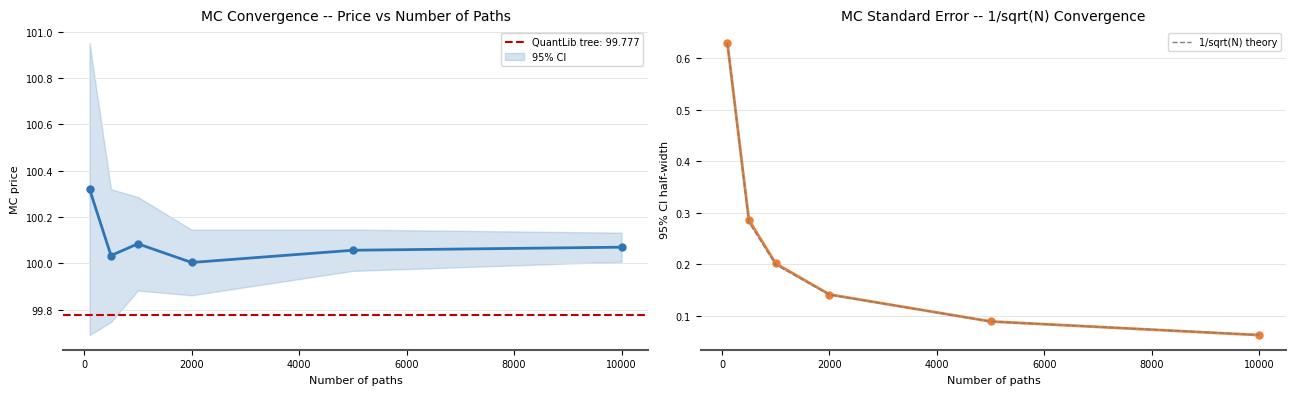

In [ ]:
# ── MC convergence analysis ───────────────────────────────────────────────────
path_counts = [100, 500, 1000, 2000, 5000, 10000]
mc_prices_conv = []
mc_errors_conv = []

for n in path_counts:
    p, se, _ = price_callable_mc_ls(
        rate_paths_mc[:n], dt_mc, coupon_rate, face,
        call_price, coupon_steps_mc, call_steps_mc
    )
    mc_prices_conv.append(p)
    mc_errors_conv.append(se * 1.96)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4))

ax0.plot(path_counts, mc_prices_conv, color=C1, linewidth=2,
             marker='o', markersize=5)
ax0.axhline(price_callable, color=C4, linestyle='--', linewidth=1.5,
                label=f'QuantLib tree: {price_callable:.3f}')
ax0.fill_between(
    path_counts,
    [p - e for p, e in zip(mc_prices_conv, mc_errors_conv)],
    [p + e for p, e in zip(mc_prices_conv, mc_errors_conv)],
    alpha=0.2, color=C1, label='95% CI'
)
ax0.set_xlabel('Number of paths')
ax0.set_ylabel('MC price')
ax0.set_title('MC Convergence -- Price vs Number of Paths')
ax0.legend()
ax0.spines['bottom'].set_color('#555555')

ax1.plot(path_counts, mc_errors_conv, color=C2, linewidth=2,
             marker='o', markersize=5)
se_ref = mc_errors_conv[0] * np.sqrt(path_counts[0])
ax1.plot(path_counts,
             [se_ref / np.sqrt(n) for n in path_counts],
             color='grey', linestyle='--', linewidth=1, label='1/sqrt(N) theory')
ax1.set_xlabel('Number of paths')
ax1.set_ylabel('95% CI half-width')
ax1.set_title('MC Standard Error -- 1/sqrt(N) Convergence')
ax1.legend()
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

## 5. Regulatory Treatment

### IFRS 13 -- Fair Value

Callable bonds are Level 2 or Level 3 under IFRS 13:

| Classification | Condition | Inputs |
|---------------|-----------|--------|
| Level 2 | Observable market prices for similar bonds, OAS from market | OIS curve, credit spread, quoted prices |
| Level 3 | No comparable market, model-dependent | Rate vol assumption, call exercise model |

The rate volatility ($\sigma$) and call exercise model are Level 3 inputs --
they are unobservable and the valuation is sensitive to them.

**Day 1 P&L:** if the model price differs from the transaction price at inception,
IFRS 13 requires deferral of the difference (Day 1 P&L) until the instrument
matures or the inputs become observable.

### FRTB SA -- OAS as CSR Sensitivity

Under CRR3 FRTB SA, the OAS of a callable bond feeds into the CSR-NS
(Credit Spread Risk non-securitisation) delta sensitivity:

$$s_k = V_i \times CS01_i$$

Where CS01 is computed by bumping the OAS by 1bp and repricing the bond
on the tree. This is more complex than for a straight bond because the
bump also affects the call decision.

### IRRBB -- Callable Bonds in EVE

Callable bonds complicate the IRRBB EVE calculation because the cash flow
timing is uncertain -- it depends on the rate path. Under EBA/RTS/2022/10:

- Banks must model the **expected** call behaviour under each shock scenario
- A bond callable at 4% coupon is unlikely to be called in the +200bps scenario
  but very likely in the -200bps scenario
- This creates asymmetric EVE sensitivity -- the callable bond behaves like
  a longer bond when rates rise (not called) and a shorter bond when rates
  fall (called)
- Supervisory simplification: some regulators allow banks to use a
  deterministic call assumption (call at first call date if in-the-money)

In [29]:
# ── IRRBB -- callable bond EVE under shock scenarios ─────────────────────────
irrbb_shocks = {
    'Parallel +200bps': +0.0200,
    'Parallel +100bps': +0.0100,
    'Base (no shock)':   0.0000,
    'Parallel -100bps': -0.0100,
    'Parallel -200bps': -0.0200,
}

print(f"IRRBB EVE Analysis -- Callable Bond")
print(f"Base callable bond price: {price_callable:.4f}")
print(f"Base straight bond price: {price_straight:.4f}")
print()
print(f"{'Scenario':<25} {'Straight':>10} {'Callable':>10} {'ΔEVE Str':>12} {'ΔEVE Cal':>12} {'Difference':>12}")
print("-" * 85)

eve_results = []
for label, shock in irrbb_shocks.items():
    shifted_ois    = ql.YieldTermStructureHandle(
        ql.ZeroSpreadedTermStructure(
            ois_handle, ql.QuoteHandle(ql.SimpleQuote(shock))
        )
    )
    shifted_credit = ql.YieldTermStructureHandle(
        ql.ZeroSpreadedTermStructure(
            shifted_ois, ql.QuoteHandle(ql.SimpleQuote(credit_spread))
        )
    )

    straight_bond.setPricingEngine(ql.DiscountingBondEngine(shifted_credit))
    p_str = straight_bond.cleanPrice()

    hw_shocked = ql.HullWhite(shifted_credit, mean_rev, sigma_hw)
    callable_bond.setPricingEngine(
        ql.TreeCallableFixedRateBondEngine(hw_shocked, 100)
    )
    p_cal = callable_bond.cleanPrice()

    delta_eve_str = p_str - price_straight
    delta_eve_cal = p_cal - price_callable
    diff          = delta_eve_cal - delta_eve_str

    eve_results.append({
        'scenario': label, 'shock': shock,
        'p_straight': p_str, 'p_callable': p_cal,
        'dEVE_straight': delta_eve_str, 'dEVE_callable': delta_eve_cal
    })

    print(f"{label:<25} {p_str:>10.4f} {p_cal:>10.4f} "
          f"{delta_eve_str:>+10.4f}   {delta_eve_cal:>+10.4f}   {diff:>+10.4f}")

# reset engines
straight_bond.setPricingEngine(ql.DiscountingBondEngine(credit_handle))
hw_model = ql.HullWhite(credit_handle, mean_rev, sigma_hw)
callable_bond.setPricingEngine(ql.TreeCallableFixedRateBondEngine(hw_model, 100))

print()
print("Key insight: in rate-down scenarios, callable bond loses less value")
print("(price compression near call price) -- but gains less when rates rise")
print("(not called, behaves like straight bond). Asymmetric EVE profile.")

IRRBB EVE Analysis -- Callable Bond
Base callable bond price: 99.7770
Base straight bond price: 101.7468

Scenario                    Straight   Callable     ΔEVE Str     ΔEVE Cal   Difference
-------------------------------------------------------------------------------------
Parallel +200bps             92.6390    92.3916    -9.1078      -7.3854      +1.7224
Parallel +100bps             97.0811    96.3023    -4.6657      -3.4747      +1.1910
Base (no shock)             101.7468    99.7770    +0.0000      +0.0000      +0.0000
Parallel -100bps            106.6475   102.6671    +4.9007      +2.8901      -2.0106
Parallel -200bps            111.7952   105.0818   +10.0484      +5.3048      -4.7436

Key insight: in rate-down scenarios, callable bond loses less value
(price compression near call price) -- but gains less when rates rise
(not called, behaves like straight bond). Asymmetric EVE profile.


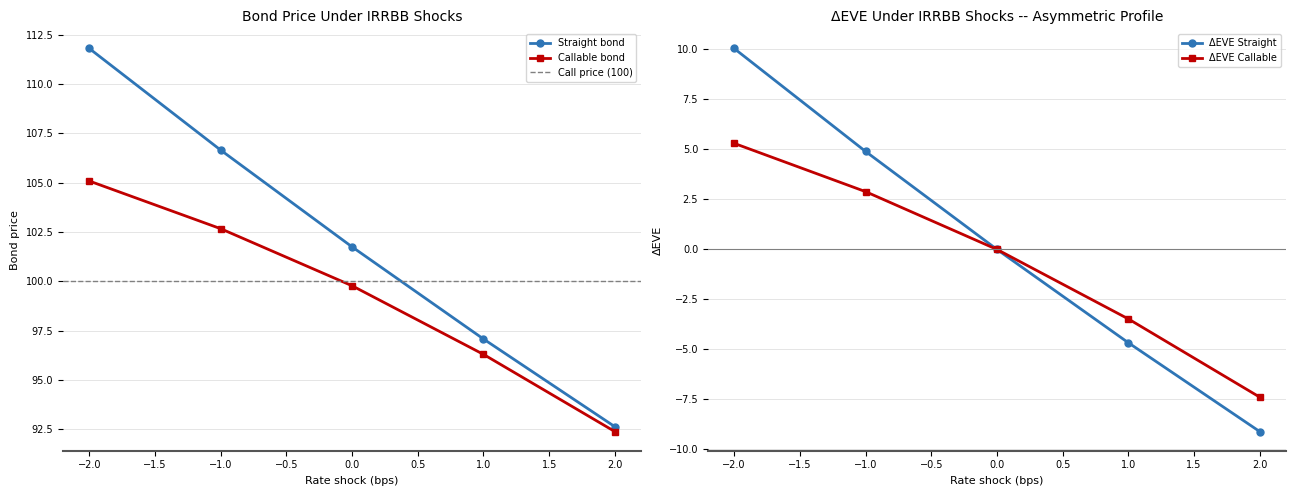

In [ ]:
# ── EVE visualisation ─────────────────────────────────────────────────────────
import pandas as pd
eve_df = pd.DataFrame(eve_results)
eve_df     = pd.DataFrame(eve_results)
shocks_bps = [r['shock'] * 100 for r in eve_results]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5))

ax0.plot(shocks_bps, eve_df['p_straight'], color=C1, linewidth=2,
             marker='o', markersize=5, label='Straight bond')
ax0.plot(shocks_bps, eve_df['p_callable'], color=C4, linewidth=2,
             marker='s', markersize=5, label='Callable bond')
ax0.axhline(call_price, color='grey', linestyle='--', linewidth=1,
                label=f'Call price ({call_price:.0f})')
ax0.set_xlabel('Rate shock (bps)')
ax0.set_ylabel('Bond price')
ax0.set_title('Bond Price Under IRRBB Shocks')
ax0.legend()
ax0.spines['bottom'].set_color('#555555')

ax1.plot(shocks_bps, eve_df['dEVE_straight'], color=C1, linewidth=2,
             marker='o', markersize=5, label='ΔEVE Straight')
ax1.plot(shocks_bps, eve_df['dEVE_callable'], color=C4, linewidth=2,
             marker='s', markersize=5, label='ΔEVE Callable')
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.set_xlabel('Rate shock (bps)')
ax1.set_ylabel('ΔEVE')
ax1.set_title('ΔEVE Under IRRBB Shocks -- Asymmetric Profile')
ax1.legend()
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

## 6. Summary -- Pricing Method Comparison

| Method | Price | Pros | Cons |
|--------|-------|------|------|
| DCF (straight) | Upper bound | Simple, transparent | Ignores optionality |
| Binomial tree | Exact (within model) | Optimal call decision, full tree visible | Discrete, slow for many steps |
| OAS | Spread measure | Model-consistent credit spread, comparable across bonds | Model-dependent |
| Monte Carlo | Flexible | Handles complex path-dependent structures | Sub-optimal call rule, slow convergence |

**Key relationships:**

$$V_{callable} = V_{straight} - V_{call\ option}$$

$$OAS < Z\text{-}spread \quad (\text{option cost} = Z\text{-}spread - OAS)$$

$$\Delta EVE_{callable} \neq \Delta EVE_{straight} \quad (\text{asymmetric -- option shortens duration in rate-down})$$

**For IFRS 13:** callable bonds are Level 2 (observable OAS) or Level 3
(model-dependent vol assumption). Rate volatility is the key Level 3 input.

**For FRTB:** CS01 must be computed by bumping OAS on the tree -- not a simple
yield bump, because the bump also affects call decisions.

**For IRRBB:** the callable bond's EVE is non-linear in rate shocks -- it
behaves like a short bond in falling rate environments (likely called) and
a long bond in rising rate environments (unlikely called).

---
*Notebook QRE-73 | Module 1 -- Yield Curves and Asset Pricing | Sprint 5*  
*Regulation: IFRS 13, CRR3 FRTB SA, EBA/RTS/2022/10 IRRBB*